# **Step2. 상품리뷰분석 Agent2**

## **0. 미션**

### 미션③ : LangSmith 기반 모니터링 시스템 구축
* [필수] 실행 Trace : 설정 및 관측 결과 확인
* [선택항목] 다음 항목은 예시 입니다.
	* 평가 : 데이터셋 구성, 평가 지표 설정 및 확인
	* 실패(혹은 오류) 케이스를 만들고 추적 및 원인 분석


### 미션④ : Agent 고도화
* [필수] Supervisor 중심 반복 제어
* [필수] DB에 쌓인 리뷰 예측 batch 처리
* [선택항목] 다음은 예시 입니다.
    - 각 에이전트 고도화 : 성능/정확도를 높이기 위한 프롬프트 개선 등
    - HITL 노드 설계 : 특정 조건 시 Human Review 전환
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### 미션⑤ : 대시보드 만들기(streamlit 기반)
* [필수] 기본 대시보드 : 리뷰 결과 집계 및 개별 정보 조회
* [선택항목] 다음은 예시 입니다.
    - 감성분석 결과에 대한 다양한 시각화
    -  Insight Agent 추가 : 요약 리포트 생성 및 개선 제안 도출
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### 워크플로우 V2.0

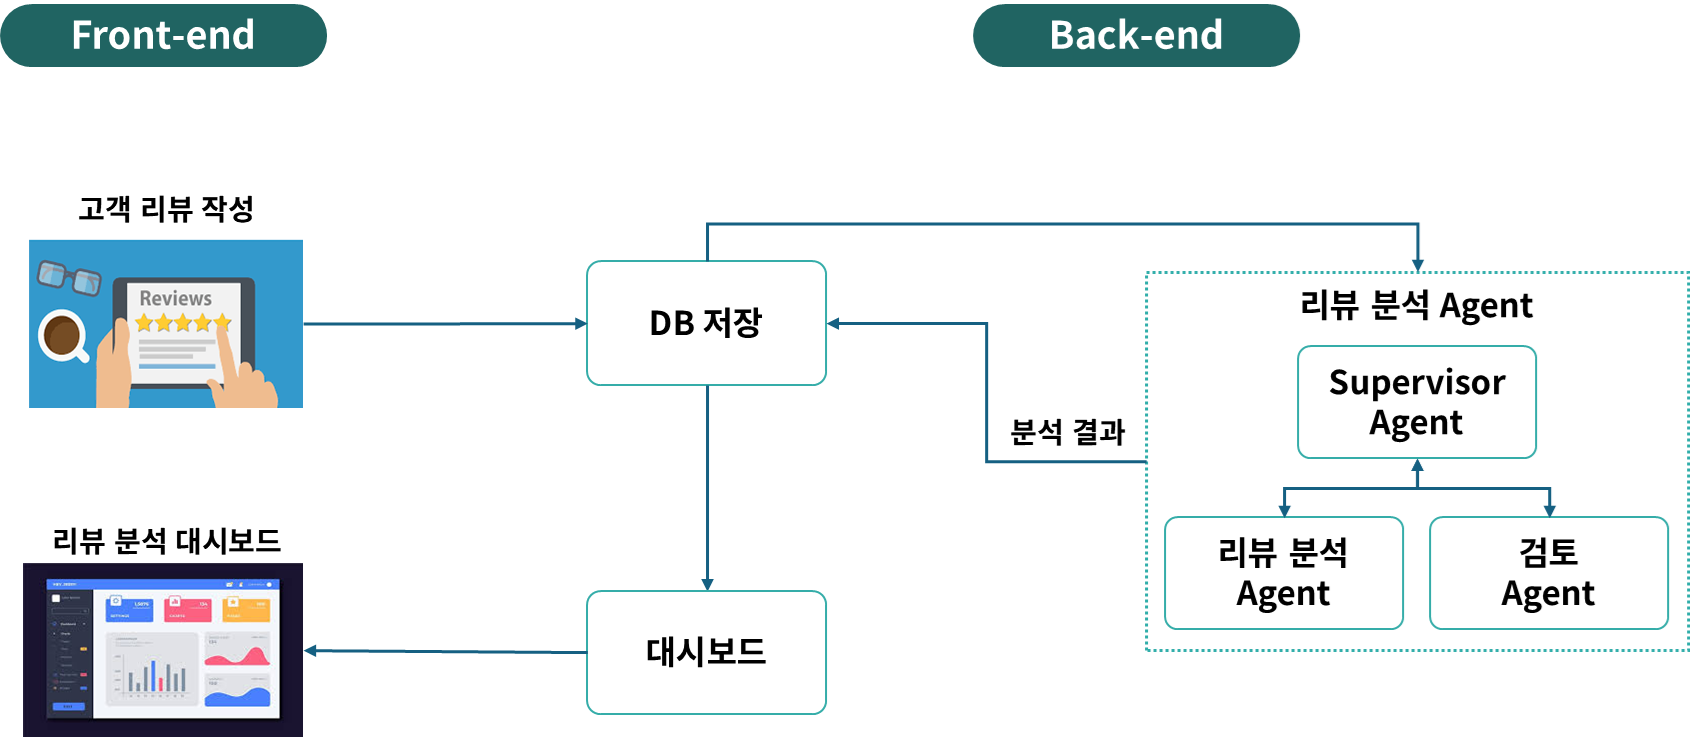

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `proj2_agent`를 생성(이미 만들었다면 skip)
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리

* 필요한 라이브러리 설치

In [ ]:
!pip install -q langchain-openai langchain-community streamlit langsmith

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.0 which is incompatible.


* 라이브러리 로딩

In [ ]:
# 기본 제공 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import os
import openai
import ast
import re

from typing import TypedDict, Annotated, List, Optional, Literal, Dict, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI

# 더 필요한 라이브러리가 있다면 추가합시다. -----
from enum import Enum
from langsmith import traceable


/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### (3) OpenAI API Key 확인

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/proj2_agent/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

## **2. 미션③ : langsmith 기반 운영 시스템**

* [필수] 실행 Trace : 설정 및 관측 결과 확인
* [선택항목] 다음 항목은 예시 입니다.
	* 평가 : 데이터셋 구성, 평가 지표 설정 및 확인
	* 실패(혹은 오류) 케이스를 만들고 추적 및 원인 분석

### **(1) langsmith 설정**

* langsmith trace에 project 추가 : `proj2_agent`


* 운영환경 설정

In [ ]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "proj2_agent"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

### **(2) Step1 결과물**
* Step1의 결과물을 아래 붙여 넣습니다.

#### **1) State & LLM 준비**

In [ ]:
'''강의자료'''
class ReviewState(TypedDict):
    # 입력 리뷰
    review: str

    # 개별 에이전트 실행 결과
    analyzer_result: Optional[Dict[str, Any]] # {"items":[{"aspect":..., "label":..., "evidence":...}, ...]}
    critic_result: Optional[Dict[str, Any]] # {"verdict":"적합|부적합", "reasons":"..."}

    # 흐름 제어
    retry_count: int
    max_retries: int
    next_agent: Literal["analyzer", "critic", "end"]


* llm 준비

In [ ]:
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)

#### **2) Agent 노드 준비**
* 필요 Agent : Analyzer Agent, Critic Agent, Supervisor Agent
* 리뷰 결과 State에 담기게 되는 형식 : Dictionary(혹은 JSON)


* Analyzer Agent

In [ ]:
def analyzer_node(state: ReviewState):
    print(f"--- [Analyzer] LLM 분석 시작 (시도: {state['retry_count'] + 1}) ---")

    sys_msg = '''
    너는 뷰엘라 코스메틱 리뷰 분석 전문가다.
    리뷰에서 [보습력, 향, 발림성, 가격, 성분] 속성을 추출하고 긍정(1)/중립(1)/부정(0)을 판별해.
    반드시 JSON 형식으로 출력: {"items": [{"aspect": "...", "label": 1, "evidence": "..."}]}
    '''
    human_msg = f"분석할 리뷰: {state['review']}"

    resp = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    try:
        content = resp.content.replace('```json', '').replace('```', '').strip()
        result = json.loads(content)
    except Exception as e:
        print(f"파싱 에러 발생: {e}")
        result = {"items": []}

    return {"analyzer_result": result, "next_agent": "critic"}

* Critic Agent

In [ ]:
def critic_node(state: ReviewState):
    print("\n[STEP] Critic Agent 실행")

    analyzer_res = state.get("analyzer_result") or {}

    sys_msg = '''
    # 역할 : 너는 리뷰 분석 결과 검토자. 칭찬/점수 매기지 말고 문제점만 찾아.
    # 검토 지침 : 아래 중 하나라도 해당하면 반드시 REVISE:
    - 추출된 속성이 리뷰 원문 내용과 맞지 않음
    - 근거(evidence)가 원문에 없는 내용임
    - 감성 라벨(1, 0) 판단이 논리적으로 부적절함
    - 뷰엘라 핵심 속성(보습, 향 등)이 명확히 언급됐는데 누락됨

    # 출력 형식(엄수):
    [문제점]
    ...
    [수정 지시]
    - ...
    [판정]
    VERDICT: OK 또는 VERDICT: REVISE
    문제점이 1개라도 있으면 VERDICT: REVISE
    '''
    human_msg = f"[리뷰 원문]\n{state['review']}\n\n[분석 결과]\n{analyzer_res}"

    resp = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    # 판정 결과 추출
    verdict = "REVISE" if "VERDICT: REVISE" in resp.content else "OK"
    next_step = "analyzer" if verdict == "REVISE" else "end"

    return {
        "critic_result": {"verdict": verdict, "reasons": resp.content},
    }

* Supervisor Agent

In [ ]:
'''Ch06. Supervisor 패턴'''

def supervisor_node(state: ReviewState):
    analyzer = state.get("analyzer_result")
    critic = state.get("critic_result")
    rev_n = state["retry_count"]
    max_rev = state["max_retries"]

    # if state["retry_count"] >= state["max_retries"]:
    #     print("최대 재시도 횟수 초과로 강제 종료")
    #     return {"next_agent": "end"}

    # 1. analyzer 없으면 analyzer 호출부터
    if not analyzer:
        return {"next_agent": "analyzer"}
    # 2. analyzer 있으나 critic 없으면 critic
    if not critic:
        return {"next_agent": "critic"}
    # 3. critic 부적합 → analyzer
    if critic.get("verdict") == "REVISE":
        if rev_n>=max_rev:
          return {"next_agent":"end"}
        return {
            "next_agent": "analyzer",
            "retry_count": rev_n+1,
            "analyzer_result":None,
            "critic_result": None
        }

    if critic.get("verdict") == "OK":
      return {"next_agent": "end"}

    return {"next_agent": "end"}

#### **3) 그래프 구성**

* route_next 함수

In [ ]:
def route_next_agent(state: ReviewState):
    return state["next_agent"]

* 그래프

In [ ]:
builder = StateGraph(ReviewState)

builder.add_node("analyzer", analyzer_node)
builder.add_node("critic", critic_node)
builder.add_node("supervisor", supervisor_node)

builder.add_edge(START, "supervisor")
builder.add_edge("analyzer", "supervisor")
builder.add_edge("critic", "supervisor")

builder.add_conditional_edges(
    "supervisor",
    route_next_agent,
    {"analyzer": "analyzer", "critic": "critic", "end": END}
)

app = builder.compile()

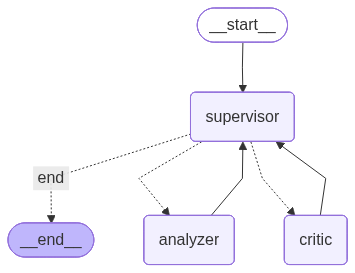

In [ ]:
app

### **(3) 추적 확인**

예제 코드를 통해 추적을 확인해 봅시다.


In [ ]:
init_state = {
    "review": "촉촉하고 좋은데, 양이 좀 부족해요.",
    "analyzer_result": None,
    "critic_result": None,
    "retry_count": 0,
    "max_retries": 3,
    "next_agent": "analyzer"
}

config = {"run_name": "Review_Agent_Test_Run"}

result = app.invoke(init_state, config=config)

--- [Analyzer] LLM 분석 시작 (시도: 1) ---

[STEP] Critic Agent 실행
--- [Analyzer] LLM 분석 시작 (시도: 2) ---

[STEP] Critic Agent 실행
--- [Analyzer] LLM 분석 시작 (시도: 3) ---

[STEP] Critic Agent 실행
--- [Analyzer] LLM 분석 시작 (시도: 4) ---

[STEP] Critic Agent 실행


## **3. 미션④ : Agent 고도화**

* [필수] Supervisor 중심 반복 제어
    - LLM 기반 흐름 제어
    - reason_code 기반 재시도 정책
* [필수] DB에 쌓인 리뷰 예측 batch 처리
* [선택항목] 다음은 예시 입니다.
    - 각 에이전트 고도화 : 성능/정확도를 높이기 위한 프롬프트 개선 등
    - HITL 노드 설계 : 특정 조건 시 Human Review 전환
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### **(1) Supervisor 중심 반복 제어**

* Supervisor Agent : 통제 정책 오케스트레이터(Policy Orchestrator)
    * Critic 판정이 ‘부적합’ 일 때 LLM은
        * critic_reason을 확인하여 reason_code 분류
        * 재시도 시 필요한 짧은 수정 지시를 repair_directive에 저장


#### **1) State 보완**

In [ ]:
class ReasonCode(str, Enum):
    OUTPUT_ERROR = "OUTPUT_ERROR"     # 형식/스키마 오류
    SCOPE_ERROR = "SCOPE_ERROR"       # 속성 범위 초과
    EVIDENCE_ERROR = "EVIDENCE_ERROR" # 근거 품질 미달
    QUALITY_ERROR = "QUALITY_ERROR"   # 개선 불가 품질 (조기 종료 대상)
    NONE = "NONE"

# reason code 정책
REPAIR_TEMPLATES = {
    "OUTPUT_ERROR": "dict 1개만 출력. 코드블록/설명 없이 items 구조와 label(0/0.5/1)을 맞춰라.",
    "SCOPE_ERROR": "aspect는 보습력, 향, 발림성, 가격, 성분, 포장만 사용하라. 다른 표현은 가장 가까운 값으로 매핑하라.",
    "EVIDENCE_ERROR": "evidence는 리뷰 원문에 실제로 있는 연속된 문구만 사용하라.",
    "QUALITY_ERROR": "리뷰에 없는 내용을 만들지 말고, 애매하면 해당 aspect는 제외하라."
}

In [ ]:
class ReviewState(TypedDict):
    review: str
    analyzer_result: Optional[Dict[str, Any]]
    critic_result: Optional[Dict[str, Any]]

    # 고도화 제어 필드
    reason_code: Optional[ReasonCode]    # Enum 타입 적용
    repair_directive: Optional[str]      # Supervisor의 처방전

    retry_count: int
    max_retries: int
    next_agent: Literal["analyzer", "critic", "end"]

#### **2) Agent 노드 준비**

In [ ]:
# 딕셔너리 파싱 함
def parse_dict(text, default):
    try:
        return ast.literal_eval(text)
    except:
        return default

* Analyzer Agents 보완

In [ ]:
def analyzer_node(state: ReviewState):
    print(f"--- [Analyzer] LLM 분석 시작 (시도: {state['retry_count'] + 1}) ---")
    # 리뷰 및 이전 critic 피드백
    review = state['review']
    reason_code = state.get("reason_code")
    repair_directive = state.get("repair_directive")

    sys_msg = '''
    # 역할: 너는 고객들의 리뷰를 보고 핵심 정보들을 분석하는 뷰엘라 코스메틱 리뷰 분석 전문가야.

    # 지침
    1. 문장 단위 분석 (Parsing):
       - 입력된 리뷰를 먼저 문장 단위로 파싱하여 각 문장이 어떤 속성(aspect)을 담고 있는지 판단해.

    2. 속성 및 근거 매칭 (Aspect-Evidence Pairing):
       - 추출된 각 아이템에 대해 'evidence' 필드에는 반드시 해당 판단의 근거가 된 리뷰 원문 속의 실제 문장을 그대로 담아.
       - 한 문장에 여러 속성이 있다면 문장을 적절히 분리하여 각각의 evidence로 지정해.
       - 원문을 절대로 요약하거나 임의로 수정하지 마.

    3. 속성 추출 (aspect): [보습력, 향, 발림성, 가격, 성분, 포장]
       - 반드시 위 6가지 카테고리 내에서만 분류해.

    4. 감성 판별 (Label):
       - 1: 확실한 긍정
       - 0.5: 중립 (보통, 사실 나열, 애매함)
       - 0: 확실한 부정

    5. 만약 이전 Critic 피드백(특히 REVISE)이 제공된다면:
       - [Reason Code] 섹션을 통해 기존 분석의 오류를 파악해.
       - [Repair Directive] 섹션의 가이드라인을 최우선으로 반영하여 결과(JSON)를 다시 생성해.

    반드시 JSON 형식으로 출력해

    # 출력 형식
    {"items": [{"aspect": "...", "label": 1, "evidence": "..."}]}
    '''
    human_msg = f"분석할 리뷰: {review}"
    if reason_code:
        human_msg += f"\n[Reason Code]\n{reason_code}\n"
    if repair_directive:
        human_msg += f"\n[Repair Directive]\n{repair_directive}\n"

    resp = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    try:
        content = resp.content.replace('```json', '').replace('```', '').strip()
        result = json.loads(content)
    except Exception as e:
        print(f"파싱 에러 발생: {e}")
        result = {"items": []}

    return {"analyzer_result": result}

* Critic Agent 보완

In [56]:
def critic_node(state: ReviewState):
    print(f"\n[STEP] Critic Agent 실행")

    review = state.get("review", "")
    analyzer_result = state.get("analyzer_result", {})


    sys_msg = '''
    # 역할: 너는 상품 리뷰 분석 결과의 논리성과 정확성을 검증하는 품질 평가 전문가야.

    # 검토 지침 : 아래 중 하나라도 해당하면 반드시 REVISE로 판정해:
    - 추출된 속성(aspect)이 원문에서 언급한 내용과 전혀 다를 경우
    - 'evidence'로 제시된 문장이 해당 'aspect'와 상관 없을 경우
    - 감성 라벨(긍정 1, 부정 0, 중립0.5)이 리뷰 내용과 논리적으로 상충할 시
    - 리뷰 원문에 핵심 속성(보습력, 향, 발림성, 가격, 성분, 포장)이 분명히 언급되었음에도 분석 결과에서 누락된 경우
    - 핵심 속성에 포함되지 않는 애매한 문장은 무시

    # 출력 형식(JSON):
    반드시 아래 JSON 구조로만 응답하고, 다른 설명은 생략해.
    {
        "reason": "문제점이 있다면 구체적 사유 작성, 없다면 '없음'",
        "verdict": "OK" 또는 "REVISE"
    }
    '''

    human_msg = f"[review]\n{review}\n\n[analyzer_result]]\n{json.dumps(analyzer_result, ensure_ascii=False)}"

    # 4. LLM 호출
    resp = llm.invoke([
        SystemMessage(content=sys_msg),
        HumanMessage(content=human_msg)
    ])

    # 5. 결과 파싱 및 처리
    res_data = json.loads(resp.content)
    verdict = res_data.get("verdict", "REVISE")
    reason = res_data.get("reason", "분석 결과 파싱 실패")

    # 6. 최종 반환
    return {
        "critic_result": {
            "verdict": verdict,
            "reasons": reason
        }
    }

* Supervisor Agent 보완

In [ ]:
def supervisor_node(state: ReviewState):
    analyzer = state.get("analyzer_result")
    critic = state.get("critic_result")
    rev_n = state.get("retry_count")
    max_rev = state.get("max_retries")

    # 최초 분석 진입
    if not analyzer:
        return {"next_agent": "analyzer"}

    # 리뷰 검수 진입
    if not critic:
        return {"next_agent": "critic"}

    # 판정 결과 확인
    verdict = critic.get("verdict")
    reason_text = critic.get("reasons", "")

    # 종료 판단: OK
    if verdict == "OK":
        return {
            "next_agent": "end",
            "reason_code": ReasonCode.NONE,
            "repair_directive": None
        }

    # 오케스트레이션 수행: REVISE
    if verdict == "REVISE":
        # 오류 진단: 비정형 사유를 표준 ReasonCode로 분류
        assigned_code = classify_reason(reason_text)

        # 품질 한계 정책: QUALITY_ERROR는 반복해도 개선이 어려우므로 즉시 종료
        if assigned_code == ReasonCode.QUALITY_ERROR:
            return {
                "next_agent": "end",
                "reason_code": assigned_code
            }

        # 강제 종료: 최대 재시도 횟수 초과 시 종료
        if rev_n >= max_rev:
            return {
                "next_agent": "end",
                "reason_code": assigned_code
            }

        # 교정 지시: 분류된 코드에 맞는 템플릿과 피드백을 결합하여 지시서 생성
        base_template = REPAIR_TEMPLATES.get(assigned_code.value, "정확하게 분석하라.")
        directive = f"[{assigned_code}] {base_template}\n(상세 피드백: {reason_text})"

        # 재시도 수행 (카운트 증가 및 기존 결과 초기화)
        return {
            "next_agent": "analyzer",
            "retry_count": rev_n + 1,
            "reason_code": assigned_code,
            "repair_directive": directive,
            "analyzer_result": None,
            "critic_result": None
        }

    # 예외 상황 방어 로직
    return {"next_agent": "end"}

In [ ]:
# 분류를 돕는 함수
@traceable(name="Reason_Classifier")
def classify_reason(reason_text: str) -> ReasonCode:
    """Critic의 사유를 분석하여 ReasonCode Enum으로 분류하는 내부 함수"""
    # LLM이 Enum 멤버 명칭 중 하나만 정확히 출력하도록 유도
    diagnosis_prompt = f"""
    당신은 품질 관리자입니다. 다음 [Critic 사유]를 분석하여 가장 적절한 ReasonCode 하나만 선택하세요.

    [사유]: {reason_text}

    [선택지]:
    - OUTPUT_ERROR: 출력 형식, JSON 스키마, 데이터 구조 오류
    - SCOPE_ERROR: 허용되지 않은 속성(Aspect) 사용 또는 매핑 실패
    - EVIDENCE_ERROR: 근거(Evidence) 문구 불일치 또는 품질 문제
    - QUALITY_ERROR: 환각(Hallucination), 논리 결여, 반복해도 개선 불가한 오류

    반드시 위 4가지 코드 중 하나만 텍스트로 출력하세요.
    """

    response = llm.invoke(diagnosis_prompt).content.strip()

    # Enum 변환 및 예외 처리
    try:
        # 응답 텍스트에서 불필요한 특수문자 제거 후 매칭
        clean_res = response.upper().replace('"', '').replace("'", "")
        return ReasonCode(clean_res)
    except ValueError:
        # 분류가 모호한 경우 품질 에러로 보수적 처리
        return ReasonCode.QUALITY_ERROR

* route_next 함수

In [ ]:
def route_next(state: ReviewState):
    return state.get("next_agent", "end")

* 그래프

In [ ]:
workflow = StateGraph(ReviewState)

workflow.add_node("supervisor", supervisor_node)
workflow.add_node("analyzer", analyzer_node)
workflow.add_node("critic", critic_node)

workflow.add_edge(START, "supervisor")
workflow.add_edge("analyzer", "supervisor")
workflow.add_edge("critic", "supervisor")

workflow.add_conditional_edges(
    "supervisor",
    route_next,
    {
        "analyzer": "analyzer",
        "critic": "critic",
        "end": END,
    },
)

graph = workflow.compile()

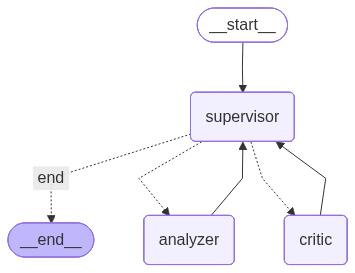

In [ ]:
graph

* 실행 테스트

In [ ]:
test_review = "향이 은은하고 촉촉해서 좋아요. 다만 가격은 조금 비싼 편이고 포장이 튼튼해요."

init_state = {
    "review": test_review,
    "analyzer_result": None,
    "critic_result": None,
    "reason_code": ReasonCode.NONE,
    "repair_directive": None,
    "retry_count": 0,
    "max_retries": 3,
    "next_agent": "analyzer",
}

result = graph.invoke(
    init_state,
    config={"run_name": "Mission4_test"}
)

result

--- [Analyzer] LLM 분석 시작 (시도: 1) ---

[STEP] Critic Agent 실행


{'review': '향이 은은하고 촉촉해서 좋아요. 다만 가격은 조금 비싼 편이고 포장이 튼튼해요.',
 'analyzer_result': {'items': [{'aspect': '향',
    'label': 1,
    'evidence': '향이 은은하고 촉촉해서 좋아요.'},
   {'aspect': '보습력', 'label': 1, 'evidence': '향이 은은하고 촉촉해서 좋아요.'},
   {'aspect': '가격', 'label': 0, 'evidence': '다만 가격은 조금 비싼 편이고'},
   {'aspect': '포장', 'label': 1, 'evidence': '포장이 튼튼해요.'}]},
 'critic_result': {'verdict': 'OK',
  'reasons': "보습력에 대한 근거 문장이 '향이 은은하고 촉촉해서 좋아요.'로 되어 있으나, '촉촉하다'는 보습력과 관련 있으나 문장 전체가 향과 보습력을 함께 언급하고 있어 혼동의 여지가 있음. 다만, '촉촉해서 좋아요'는 보습력 긍정으로 해석 가능하므로 근거 문장으로 인정 가능. 따라서 문제 없음."},
 'reason_code': <ReasonCode.NONE: 'NONE'>,
 'repair_directive': None,
 'retry_count': 0,
 'max_retries': 3,
 'next_agent': 'end'}

### **(2) DB에 쌓인 리뷰 예측 batch 처리**

* 리뷰 데이터 여러 건을 임의로 생성하여 Step1에서 생성한 DB의 테이블에 저장.
* DB에서 분석 대상 리뷰 조회(예: agent_aspect가 NULL인 데이터)
* 각 리뷰에 대해 Agent 실행
* 분석 결과(items)에서 aspect , label 추출
* DB에 결과 저장 (UPDATE)


#### **1) 데이터 준비**
* data.csv 파일 로딩
* review 칼럼의 값만 DB에 저장

In [ ]:
# 코랩에 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [51]:
# 파일 로드
df = pd.read_csv('data.csv')

# DB 연결
path = '/content/drive/MyDrive/proj2_agent/'
db_path = path + "reviews.db"
conn = sqlite3.connect(db_path)

# review 칼럼의 값만 DB에 저장
df[['review']].to_sql('product_reviews', conn, if_exists='append', index=False)

conn.commit()

# 잘 들어갔는지 확인
check_df = pd.read_sql("SELECT * FROM product_reviews LIMIT 5", conn)
print("--- DB 저장 결과 확인 ---")
print(check_df)

conn.close()

--- DB 저장 결과 확인 ---
   id                                             review  \
0   1                   보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요.   
1   2  연령상관없이 요즘 너무 인기 있어서 한번 사봤습니다. 도대체 얼마나 좋길래 다들 O...   
2   3  구매후 3일정도 사용하고 후기 작성하는데요. 최근 들어 탈모가 심해지는것 같아서 탈...   
3   4  친구랑 같이 기숙사에 사는데 어느 날 친구가 이 향수를 사 왔더라구요?? 향이 어떨...   
4   5  써보고 주위 선물 하려고 샀어요. 눈 주위에 바르고 있는데 덜 건조하고 촉촉해요 휴...   

                      agent_aspect              agent_label  \
0                ["보습", "향", "가격"]                [1, 1, 0]   
1                     ["가격", "구성"]                 [0, 0.5]   
2                     ["향", "발림성"]                 [1, 0.5]   
3                            ["향"]                      [1]   
4  ["보습력", "향", "발림성", "가격", "성분"]  [1, 0.5, 0.5, 0.5, 0.5]   

             update_at  
0  2026-05-12 11:59:03  
1  2026-05-13 05:14:30  
2  2026-05-13 05:14:34  
3  2026-05-13 05:14:49  
4  2026-05-13 05:15:05  


#### **2) 리뷰를 읽어서 Agent 실행후 결과 저장**

In [52]:
# 함수 생성

# 1) 미처리 리뷰 조회 함수
def get_unprocessed_reviews(db_path):
    conn = sqlite3.connect(db_path)
    query = "SELECT id, review FROM product_reviews WHERE agent_aspect IS NULL"
    df = pd.read_sql(query, conn)
    conn.close()
    return df


# 2) Agent 결과에서 aspect, label 추출 함수
def parse_agent_results(result):
    try:
        analyzer_result = result.get("analyzer_result", {}) or {}
        items = analyzer_result.get("items", [])

        aspects = [item.get("aspect") for item in items]
        labels = [item.get("label") for item in items]

        return json.dumps(aspects, ensure_ascii=False), json.dumps(labels, ensure_ascii=False)
    except Exception as e:
        print(f"Parsing Error: {e}")
        return None, None


# 3) DB 업데이트
def update_review_in_db(db_path, row_id, aspect_str, label_str):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    sql = """
        UPDATE product_reviews
        SET agent_aspect = ?,
            agent_label = ?,
            update_at = DATETIME('now', 'localtime')
        WHERE id = ?
    """
    cursor.execute(sql, (aspect_str, label_str, row_id))
    conn.commit()
    conn.close()


# 4) batch 실행
def run_batch_process(db_path, graph, limit=None):
    df = get_unprocessed_reviews(db_path)

    if limit is not None:
        df = df.head(limit)

    print(f"총 {len(df)}건의 미처리 리뷰 분석 시작...")

    for _, row in df.iterrows():
        print(f"ID {row['id']} 분석 중...")

        # tracing log 용
        config = create_langsmith_config(row['id'])

        init_state = {
            "review": row["review"],
            "analyzer_result": None,
            "critic_result": None,
            "reason_code": ReasonCode.NONE,
            "repair_directive": None,
            "retry_count": 0,
            "max_retries": 3,
            "next_agent": "analyzer",
        }

        response = graph.invoke(init_state, config=config)

        aspect_str, label_str = parse_agent_results(response)

        if aspect_str:
            update_review_in_db(db_path, row["id"], aspect_str, label_str)
            print(f"ID {row['id']} 저장 완료")

    print("모든 배치 작업이 완료~")


In [57]:
# 배치 실행: 테스트용 5건만
run_batch_process(db_path, graph, limit=5)

# 실행 결과 확인
conn = sqlite3.connect(db_path)

check_df = pd.read_sql(
    "SELECT * FROM product_reviews WHERE agent_aspect IS NOT NULL LIMIT 5",
    conn
)
conn.close()

print("\n--- 업데이트 완료 데이터 확인 ---")
display(check_df)


총 5건의 미처리 리뷰 분석 시작...
ID 20 분석 중...
--- [Analyzer] LLM 분석 시작 (시도: 1) ---

[STEP] Critic Agent 실행
--- [Analyzer] LLM 분석 시작 (시도: 2) ---

[STEP] Critic Agent 실행
--- [Analyzer] LLM 분석 시작 (시도: 3) ---

[STEP] Critic Agent 실행
--- [Analyzer] LLM 분석 시작 (시도: 4) ---

[STEP] Critic Agent 실행
ID 20 저장 완료
ID 21 분석 중...
--- [Analyzer] LLM 분석 시작 (시도: 1) ---

[STEP] Critic Agent 실행
ID 21 저장 완료
ID 22 분석 중...
--- [Analyzer] LLM 분석 시작 (시도: 1) ---

[STEP] Critic Agent 실행
ID 22 저장 완료
ID 23 분석 중...
--- [Analyzer] LLM 분석 시작 (시도: 1) ---

[STEP] Critic Agent 실행
--- [Analyzer] LLM 분석 시작 (시도: 2) ---

[STEP] Critic Agent 실행
ID 23 저장 완료
ID 24 분석 중...
--- [Analyzer] LLM 분석 시작 (시도: 1) ---

[STEP] Critic Agent 실행
--- [Analyzer] LLM 분석 시작 (시도: 2) ---

[STEP] Critic Agent 실행
--- [Analyzer] LLM 분석 시작 (시도: 3) ---

[STEP] Critic Agent 실행
--- [Analyzer] LLM 분석 시작 (시도: 4) ---

[STEP] Critic Agent 실행
ID 24 저장 완료
모든 배치 작업이 완료~

--- 업데이트 완료 데이터 확인 ---


,id,review,agent_aspect,agent_label,update_at
0,1,보습력이 정말 좋아요. 향도 괜찮지만 가격은 조금 비싸요.,"[""보습"", ""향"", ""가격""]","[1, 1, 0]",2026-05-12 11:59:03
1,2,연령상관없이 요즘 너무 인기 있어서 한번 사봤습니다. 도대체 얼마나 좋길래 다들 O...,"[""가격"", ""구성""]","[0, 0.5]",2026-05-13 05:14:30
2,3,구매후 3일정도 사용하고 후기 작성하는데요. 최근 들어 탈모가 심해지는것 같아서 탈...,"[""향"", ""발림성""]","[1, 0.5]",2026-05-13 05:14:34
3,4,친구랑 같이 기숙사에 사는데 어느 날 친구가 이 향수를 사 왔더라구요?? 향이 어떨...,"[""향""]",[1],2026-05-13 05:14:49
4,5,써보고 주위 선물 하려고 샀어요. 눈 주위에 바르고 있는데 덜 건조하고 촉촉해요 휴...,"[""보습력"", ""향"", ""발림성"", ""가격"", ""성분""]","[1, 0.5, 0.5, 0.5, 0.5]",2026-05-13 05:15:05


### LangSmith Trace
* LangSmith 추적을 위한 Config 설정을 생성하는 함수

In [ ]:
from datetime import datetime

def create_langsmith_config(row_id: int, model_name: str = "gpt-4o-mini"):
    """
    LangSmith 추적을 위한 Config 설정을 생성하는 함수
    """
    return {
        "run_name": f"Review_Batch_ID_{row_id}", # 실행 단위 명칭
        "metadata": {
            "row_id": row_id,
            "model": model_name,
            "batch_date": datetime.now().strftime('%Y-%m-%d'),
            "environment": "production"
        },
        "tags": ["batch_process", "v2_advanced_agent"]
    }

## **4. 미션⑤ : 대시보드 만들기**

### (1) 한글 폰트 준비

* 한글폰트 설치

In [ ]:
!apt-get -y install fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (31.5 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


* 세션 다시시작

### **(2) 대시보드 앱 : app.py**

* 최소 요구사항
    * 프레임1 : 상품리뷰 결과를 분석하는 그래프
    * 프레임2 : 리뷰 분석 결과 건별 조회


In [ ]:
%%writefile app.py
import json
import sqlite3
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns

# 한글 폰트 세팅 -------------------------------
def set_korean_font():
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    try:
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        mpl.rcParams["font.family"] = font_name
        mpl.rcParams["axes.unicode_minus"] = False
        sns.set_theme(style="whitegrid", rc={"font.family": font_name, "axes.unicode_minus": False})
    except:
        pass

set_korean_font()

# -----------------------------
# 1. 데이터 연결 및 가공
# -----------------------------
db_path = '/content/drive/MyDrive/proj2_agent/reviews.db'

def load_data():
    conn = sqlite3.connect(db_path)
    # 1. 분석 완료된 원본 데이터 가져오기
    query = "SELECT id, review, agent_aspect, agent_label, update_at as updated_at FROM product_reviews WHERE agent_aspect IS NOT NULL"
    df = pd.read_sql(query, conn)
    conn.close()

    # 2. UI에서 사용할 'prediction' 컬럼 생성 (JSON 합치기)
    # DB의 두 컬럼을 합쳐서 [{"aspect": "보습", "label": 1}, ...] 형태로 만듦
    def combine_to_prediction(row):
        aspects = json.loads(row['agent_aspect'])
        labels = json.loads(row['agent_label'])
        combined = []
        for a, l in zip(aspects, labels):
            combined.append({"aspect": a, "label": float(l)})
        return json.dumps(combined, ensure_ascii=False)

    df['prediction'] = df.apply(combine_to_prediction, axis=1)

    # 3. 집계용 데이터프레임(stat_df) 생성
    rows = []
    for _, row in df.iterrows():
        items = json.loads(row['prediction'])
        for item in items:
            val = item.get('label')
            if val == 1: label_str = "긍정"
            elif val == 0.5: label_str = "중립"
            else: label_str = "부정"

            rows.append({
                "id": row['id'],
                "aspect": item['aspect'],
                "label": label_str
            })
    stat_df = pd.DataFrame(rows)

    return df, stat_df

# 데이터 로드
try:
    df, stat_df = load_data()
except Exception as e:
    st.error(f"데이터 로드 실패: {e}")
    st.stop()

# -----------------------------
# 2. Streamlit UI
# -----------------------------
st.set_page_config(layout="wide")
st.title("상품 리뷰 분석 Agent")

# --- 프레임 1: 건별 조회 ---
st.subheader("📂 리뷰 분석 결과 건별 조회")
selected_id = st.selectbox("조회할 id 선택", options=df['id'].tolist())

if selected_id:
    detail = df[df['id'] == selected_id].iloc[0]
    c1, c2 = st.columns([1, 1])

    with c1:
        st.write("**리뷰 원문**")
        st.info(detail['review'])
        st.write(f"**업데이트 시각**: {detail['updated_at']}")

    with c2:
        st.write("**예측 결과**")
        pred_data = json.loads(detail['prediction'])
        pred_df = pd.DataFrame(pred_data)
        # label 숫자를 한글로 매핑
        pred_df['label'] = pred_df['label'].map({1.0: "긍정", 0.5: "중립", 0.0: "부정"})
        st.table(pred_df)

st.divider()

# --- 프레임 2: 집계 그래프 ---
st.subheader("📊 리뷰 분석 결과 집계")

desired_order = ["가격", "보습력", "향", "발림성", "성분", "포장"]

# 피벗 테이블 생성
pivot_df = stat_df.groupby(['aspect', 'label']).size().unstack(fill_value=0)

# 컬럼 순서 및 존재 여부 보정
for col in ["긍정", "중립", "부정"]:
    if col not in pivot_df.columns:
        pivot_df[col] = 0

st.table(pivot_df[["긍정", "중립", "부정"]])

st.divider()

# 그래프 그리기
fig, ax = plt.subplots(figsize=(10,7))
plt.title('속성별 감성 분석')
sns.countplot(data=stat_df, x='aspect', hue='label', order=desired_order,
              palette='pastel', ax=ax)
plt.xlabel('속성')
plt.ylabel('건수')
plt.legend(title='감성')
st.pyplot(fig)

Overwriting app.py


### (3) 스트림릿 실행

* Streamlit 실행 + 외부 URL 열기
    - Cloudflare tunnel로 외부 링크 생성
    - Streamlit (재)시작 (localhost로 붙이기)
    - 외부 URL 생성 및 접속

* Cloudflare tunnel로 외부 링크 생성

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

(Reading database ... 118280 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) over (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...


* Streamlit (재)시작 (localhost로 붙이기)

In [ ]:
!pkill -9 -f streamlit || true
!pkill -9 -f cloudflared || true
!rm -f streamlit.log cloudflared.log

!streamlit run app.py \
  --server.port 8501 \
  --server.address 127.0.0.1 \
  --server.headless true \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > streamlit.log 2>&1 &

^C
^C


* 외부 URL 생성 및 접속

In [ ]:
!cloudflared tunnel --url http://127.0.0.1:8501

2026-05-13T06:16:27Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-13T06:16:27Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-13T06:16:30Z INF +--------------------------------------------------------------------------------------------+
2026-05-13T06:16:30Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-13T06:16:30Z INF |  https://holly-blocks-intranet-useful.trycloudflare.co

* 주소 링크를 복사해서, 구글크롬브라우저 > 새 시크릿 창 주소에 복사해서 스트림릿 화면을 띄웁니다.